# Predicting Heart Disease using machine learning

This notebook looks into using various python-based machine learning and data science libraries in attempt to build a machine learning model capable of predicting whether or not someone has heart disease based on the medical attributes.

We're going to take the following approach:
1. Problem definition
2. Data
3. Evaluation
4. Features
5. Modelling
6. Experimentation

## 1. Problem Definition

In a statement ,
> Given Clinical parameters about a patient ,can we predict whether or not they have heart disease?

## 2 Data

# create data dictionary
This data has 14 attributes used

## 3.Evaluation

>If we can reach 95% accuracy at predicting whether or not a patient has heart disease during the proof of concept, we'll pursue the project.


## 4. Features

**Check the data dictionary to get  different information about each of the features in your data**


## Preparing the tools

We're going to use pandas,numpy,matplotlib and seaborn for data analysis and manipulation

In [2]:
# Regular EDA(Exploratory Data Analysis )
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Models from Scikit-Learn

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier

# Models Evaluation

from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score,precision_score,recall_score,roc_curve
from sklearn.metrics import RocCurveDisplay

In [3]:
df =pd.read_csv("data/heart-disease.csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [4]:
df.shape

(303, 14)

# Data Exploration (exploratory data analysis or EDA  )

The goal  here is to find out more about the data and become a subject matter expert on the dataset you're working with

1. What questions are you trying to solve ?
2. What kind of data  do we have and how do we treat different types?
3. What's missing from the data and how do you deal with it?
4. where are the outliers and why should you care about them
5. How can you add change or remove features to get more out of your data

In [5]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [6]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [7]:
df["target"].value_counts()

target
1    165
0    138
Name: count, dtype: int64

<Axes: xlabel='target'>

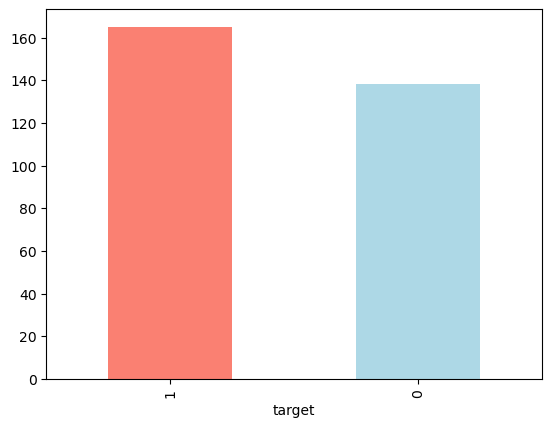

In [8]:
df["target"].value_counts().plot(kind="bar",color=["salmon","lightblue"])


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [10]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [11]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [12]:
df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trestbps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210,-0.144931
chol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803,-0.085239
fbs,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439,0.421741
exang,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696


In [13]:
df["sex"].value_counts()

sex
1    207
0     96
Name: count, dtype: int64

In [14]:
# Compare target column with sex column
pd.crosstab(df.target,df.sex)

sex,0,1
target,,
0,24,114
1,72,93


(array([0, 1]), [Text(0, 0, '0'), Text(1, 0, '1')])

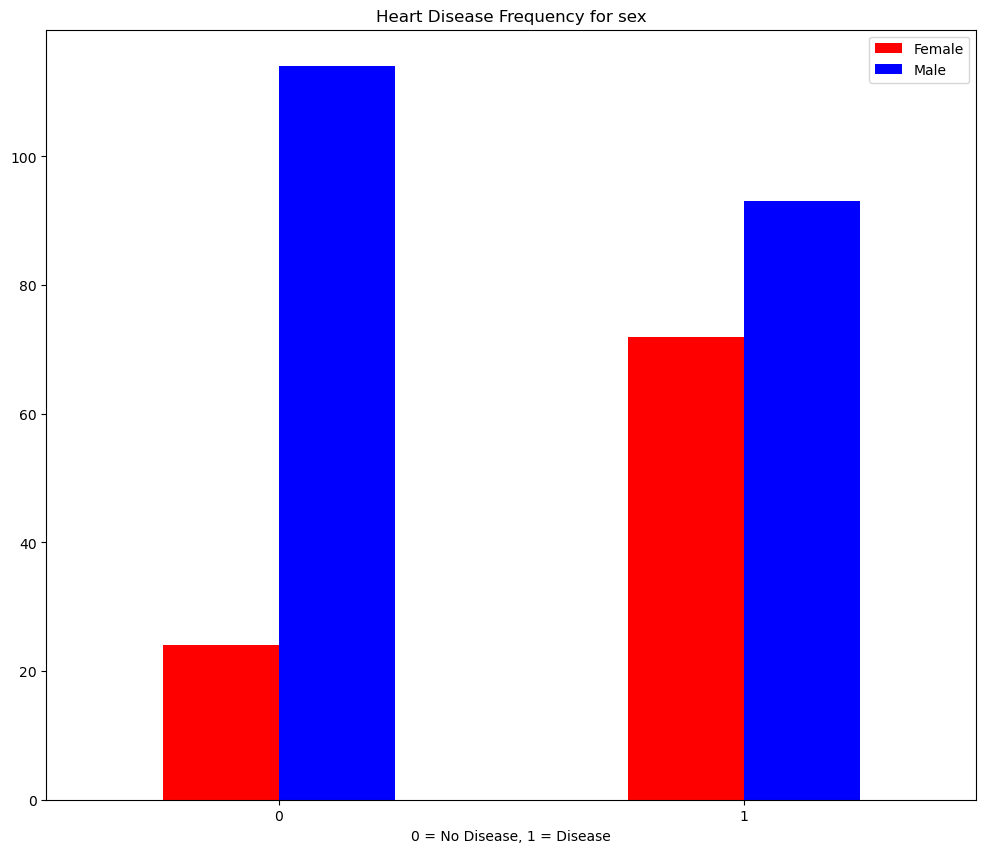

In [15]:
pd.crosstab(df["target"],df["sex"]).plot(kind="bar",
                                        figsize=(12,10),
                                        color=["red","blue"]
                                        )
plt.title("Heart Disease Frequency for sex")
plt.xlabel("0 = No Disease, 1 = Disease")
# plt.ylabel("Amount")
plt.legend(["Female","Male"])
plt.xticks(rotation=0)

# Age vs Max Heart rate for Heart disease

Text(0, 0.5, 'Max heart Rate')

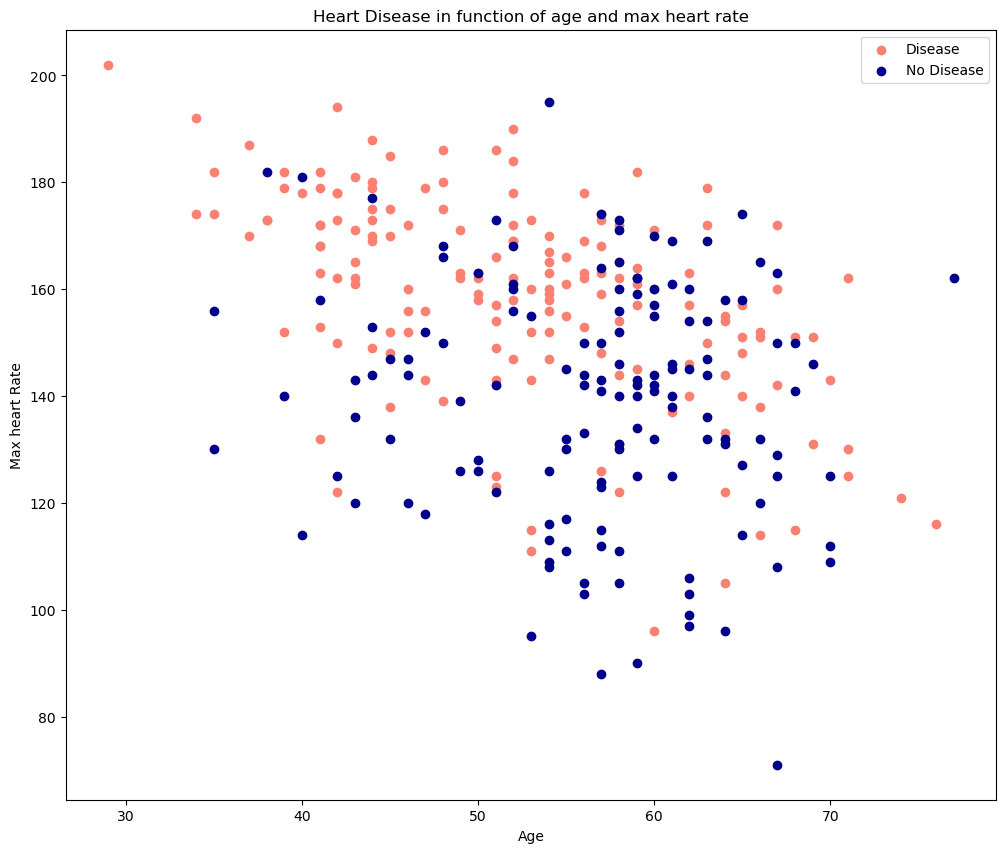

In [16]:
# Scatter with positive examples
plt.figure(figsize=(12,10))

plt.scatter(df["age"][df["target"]==1],df["thalach"][df["target"]==1], c="salmon")

# Scatter with negative examples
plt.scatter(df["age"][df["target"]==0],df["thalach"][df["target"]==0], c="darkblue")

plt.title("Heart Disease in function of age and max heart rate")
plt.xlabel("Age")
plt.legend(["Disease","No Disease"])
plt.ylabel("Max heart Rate")

<Axes: ylabel='Frequency'>

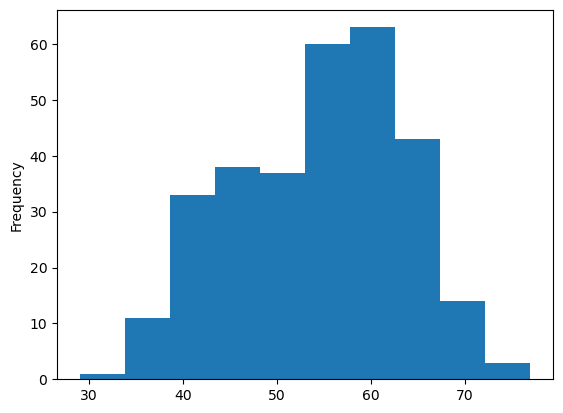

In [17]:
# Check the distribution of the age column with a histogram
# df["age"].plot.hist()
df["age"].plot(kind="hist")

# Heart Disease Frequency per chest pain Type

3.cp- Chest pain type
  > 0:Typical angina:chest pain related decrease blood supply to the heart
> 
  > 1:Atypical angina:chest pain not related to heart
> 
  > 2:Non-anginal pain:typically esophageal spasms(non heart related)
> 
  > 3:Asymptomaticchest pain not showing siggns of disease

In [18]:
pd.crosstab(df["cp"],df["target"])

target,0,1
cp,,
0,104,39
1,9,41
2,18,69
3,7,16


Text(0, 0.5, 'Amount')

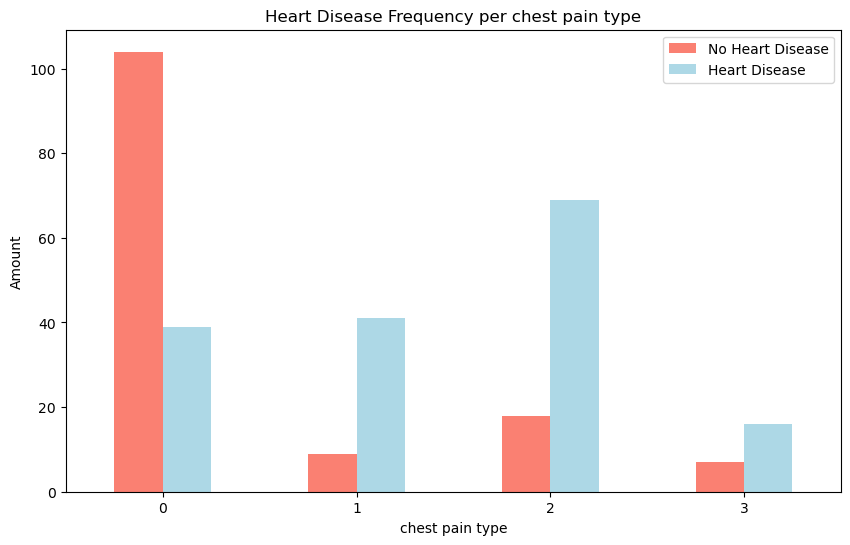

In [19]:
 # make the crosstab more visual
pd.crosstab(df["cp"],df["target"]).plot(kind="bar",
                                       figsize=(10,6),
                                       color=["salmon","lightblue"])

plt.title("Heart Disease Frequency per chest pain type")
plt.xlabel("chest pain type")

plt.legend(["No Heart Disease","Heart Disease"])
plt.xticks(rotation=0)
plt.ylabel("Amount")

In [20]:
df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trestbps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210,-0.144931
chol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803,-0.085239
fbs,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439,0.421741
exang,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696


<Axes: >

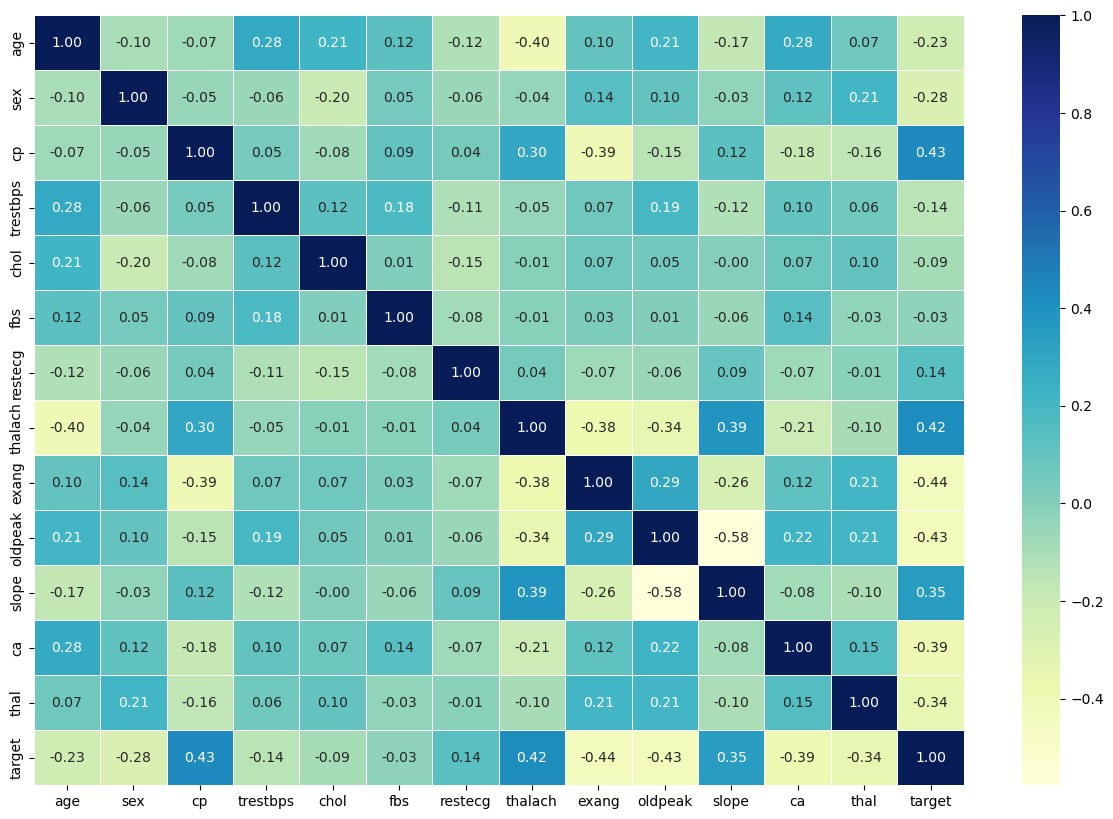

In [21]:
# Making the correlation matrix a little prettier

corr_matrix=df.corr()
fig,ax=plt.subplots(figsize=(15,10))
ax=sns.heatmap(corr_matrix,annot=True,linewidths=0.5,fmt=".2f",cmap="YlGnBu")
ax

# Modelling

In [22]:
X=df.drop("target",axis=1)
y=df["target"]

In [23]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.2,random_state=42)

In [46]:
def model_created(model,X_train,X_test,y_train,y_test):
    model=model
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)

    from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay
    from sklearn.metrics import accuracy_score,precision_score,recall_score,roc_curve,roc_auc_score
    from sklearn.metrics import RocCurveDisplay
    
    accuracy_score=accuracy_score(y_test,y_pred)
    precision_score=precision_score(y_test,y_pred)
    recall_score=recall_score(y_test,y_pred)
    fpr, tpr, thresholds=roc_curve(y_test,y_pred)

    print(f"accuracy_score:{accuracy_score}")
    print(f"precision_score:{precision_score}")
    print(f"recall_score:{recall_score}")
    print(classification_report(y_test,y_pred))
    ConfusionMatrixDisplay(confusion_matrix(y_test,y_pred)).plot()
    RocCurveDisplay(fpr=fpr, tpr=tpr).plot()

    return [accuracy_score,precision_score,recall_score]

C:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


accuracy_score:0.8852459016393442
precision_score:0.8787878787878788
recall_score:0.90625
              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



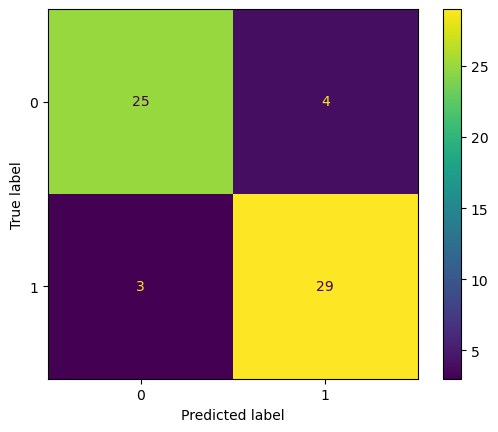

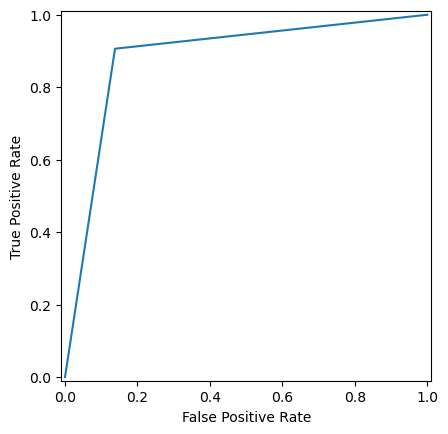

In [25]:
log_model=model_created(LogisticRegression,X_train,X_test,y_train,y_test)

accuracy_score:0.7540983606557377
precision_score:0.7428571428571429
recall_score:0.8125
              precision    recall  f1-score   support

           0       0.77      0.69      0.73        29
           1       0.74      0.81      0.78        32

    accuracy                           0.75        61
   macro avg       0.76      0.75      0.75        61
weighted avg       0.76      0.75      0.75        61



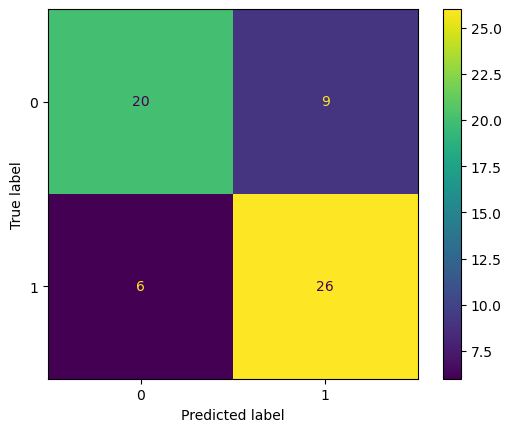

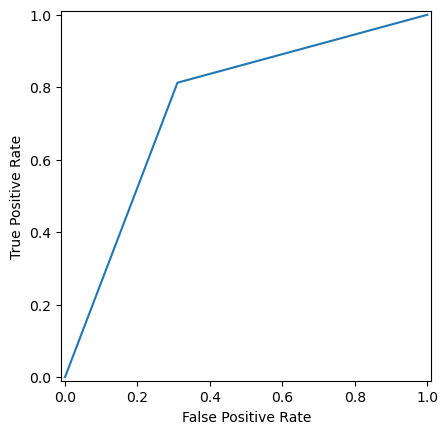

In [47]:
knn_model=model_created(KNeighborsClassifier(n_neighbors=11),X_train,X_test,y_train,y_test)

accuracy_score:0.7049180327868853
precision_score:0.6666666666666666
recall_score:0.875
              precision    recall  f1-score   support

           0       0.79      0.52      0.62        29
           1       0.67      0.88      0.76        32

    accuracy                           0.70        61
   macro avg       0.73      0.70      0.69        61
weighted avg       0.73      0.70      0.69        61



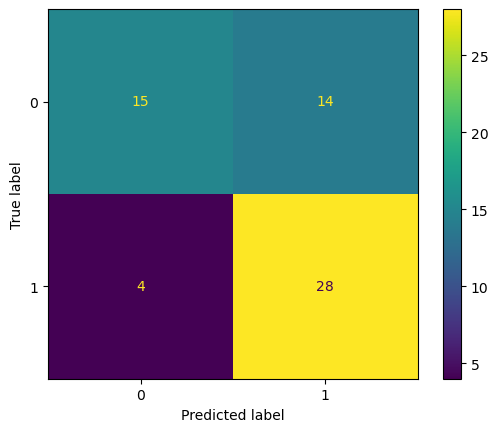

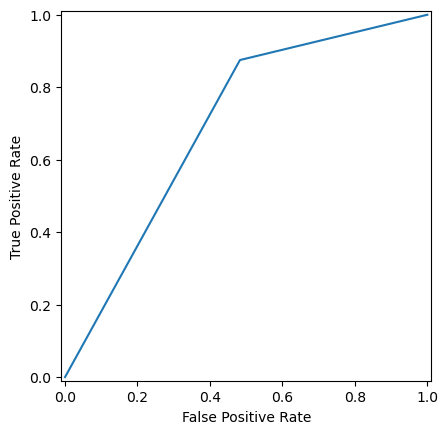

In [27]:
svm_model=model_created(SVC,X_train,X_test,y_train,y_test)

accuracy_score:0.819672131147541
precision_score:0.8888888888888888
recall_score:0.75
              precision    recall  f1-score   support

           0       0.76      0.90      0.83        29
           1       0.89      0.75      0.81        32

    accuracy                           0.82        61
   macro avg       0.83      0.82      0.82        61
weighted avg       0.83      0.82      0.82        61



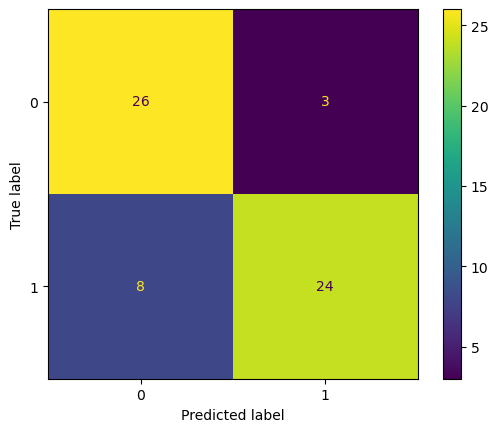

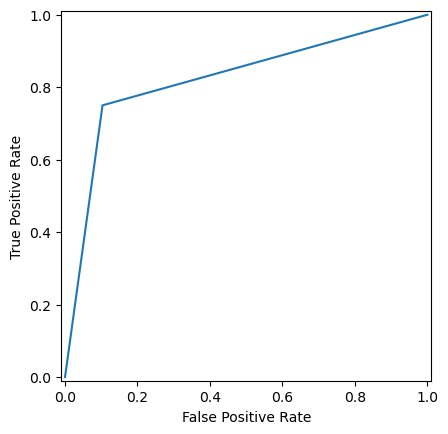

In [28]:
decision_tree_model=model_created(DecisionTreeClassifier,X_train,X_test,y_train,y_test)

accuracy_score:0.819672131147541
precision_score:0.8888888888888888
recall_score:0.75
              precision    recall  f1-score   support

           0       0.76      0.90      0.83        29
           1       0.89      0.75      0.81        32

    accuracy                           0.82        61
   macro avg       0.83      0.82      0.82        61
weighted avg       0.83      0.82      0.82        61



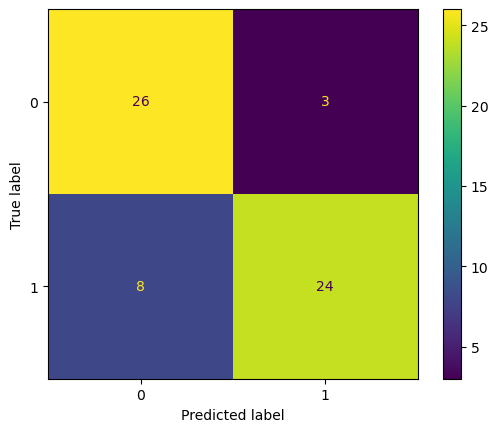

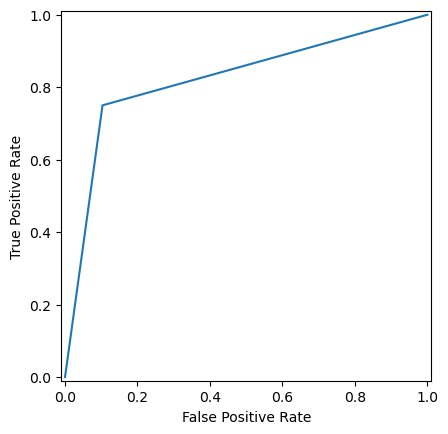

In [29]:
ada_boost_model=model_created(AdaBoostClassifier,X_train,X_test,y_train,y_test)

accuracy_score:0.8524590163934426
precision_score:0.8484848484848485
recall_score:0.875
              precision    recall  f1-score   support

           0       0.86      0.83      0.84        29
           1       0.85      0.88      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



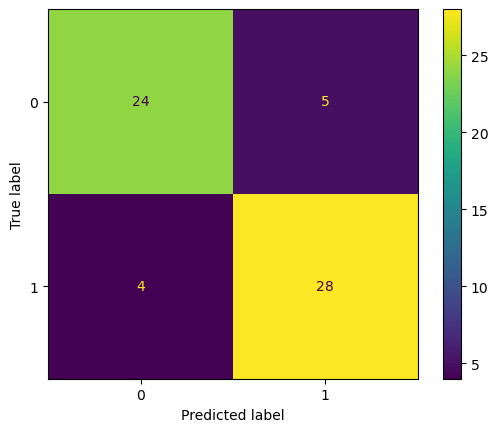

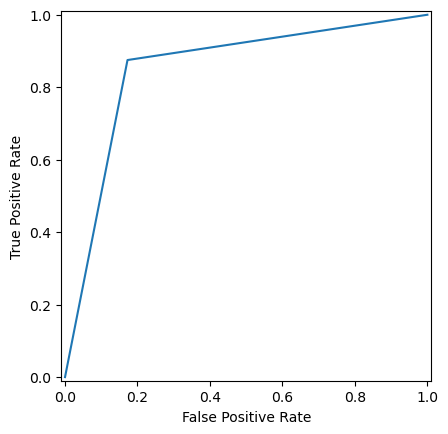

In [30]:
random_forest_model=model_created(RandomForestClassifier,X_train,X_test,y_train,y_test)

accuracy_score:0.7704918032786885
precision_score:0.8
recall_score:0.75
              precision    recall  f1-score   support

           0       0.74      0.79      0.77        29
           1       0.80      0.75      0.77        32

    accuracy                           0.77        61
   macro avg       0.77      0.77      0.77        61
weighted avg       0.77      0.77      0.77        61



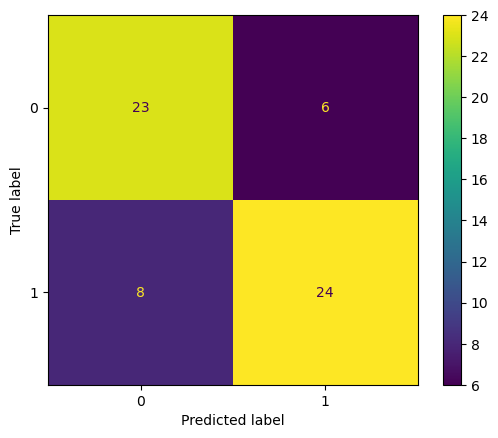

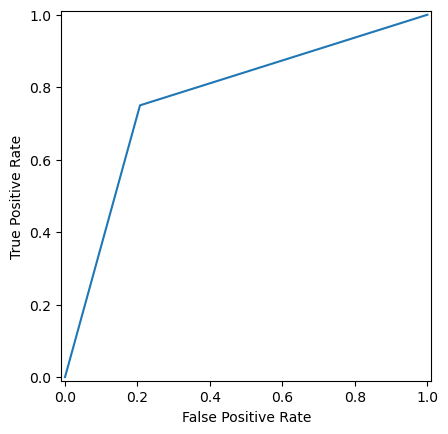

In [31]:
gradient_boost_model=model_created(GradientBoostingClassifier,X_train,X_test,y_train,y_test)

In [32]:
my_dict={"Logictic_model":log_model,
        "KNN_mode":knn_model,
        "svm_mosel":svm_model,
        "Decision_tree_model":decision_tree_model,
        "Random_forest_model":random_forest_model,
        "ada_boost_model":ada_boost_model,
        "gradien_boost_model":gradient_boost_model}
data_f=pd.DataFrame(my_dict,index=["accuracy","precision","recall"])


In [33]:
data_f

,Logictic_model,KNN_mode,svm_mosel,Decision_tree_model,Random_forest_model,ada_boost_model,gradien_boost_model
accuracy,0.885246,0.688525,0.704918,0.819672,0.852459,0.819672,0.770492
precision,0.878788,0.685714,0.666667,0.888889,0.848485,0.888889,0.800000
recall,0.906250,0.750000,0.875000,0.750000,0.875000,0.750000,0.750000


In [49]:
log_param_grid={"penalty":['l1', 'l2', 'elasticnet'],
               "C":[0.1,0.5,1,2,],
               "solver":['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'],
               "l1_ratio":[0.1,0.5,0.6]}
svm_param_grid={"C":[0.1,0.5,1,2,3],
               "kernel":["linear","poly","rbf","sigmoid"],
               "degree":[2,3,4,5,6],
               "gamma":['scale','auto']}
knn_param_grid={"n_neighbors":[3,4,5,6,7,8,11],
               "algorithm":['auto','ball_tree','kd_tree','brute']}
tree_param_grid={"criterion":["gini","entropy","log_loss"],
                "max_features":["sqrt","log2",4,6,3,2]}

forest_param_grid={"n_estimators":[50,80,100,150,200,400,500],
                  "criterion": ["gini", "entropy", "log_loss"],
                  "max_features":["sqrt","log2"],
                  "bootstrap":[True,False]}
ada_param_grid={"n_estimators":[50,100,200,400]}

gradient_param_grid={"n_estimators":[50,80,100,150,200,400,500],
                    "loss" : ['log_loss', 'exponential'] ,
                    "max_depth":[3,4,5,6,7],
                    "max_features":[4,3,6,'sqrt',"log2"],
                    }

In [52]:
def model_created(model,param_grid,X_train,X_test,y_train,y_test):
    
    grid_model=GridSearchCV(model(),param_grid=param_grid,verbose=1)
    grid_model.fit(X_train,y_train)
    y_pred=grid_model.predict(X_test)

    from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay
    from sklearn.metrics import accuracy_score,precision_score,recall_score,roc_curve,roc_auc_score
    from sklearn.metrics import RocCurveDisplay
    
    accuracy_score=accuracy_score(y_test,y_pred)
    precision_score=precision_score(y_test,y_pred)
    recall_score=recall_score(y_test,y_pred)
    fpr, tpr, thresholds=roc_curve(y_test,y_pred)

    print(f"accuracy_score:{accuracy_score}")
    print(f"precision_score:{precision_score}")
    print(f"recall_score:{recall_score}")
    print(classification_report(y_test,y_pred))
    ConfusionMatrixDisplay(confusion_matrix(y_test,y_pred)).plot()
    RocCurveDisplay(fpr=fpr, tpr=tpr).plot()

    return [accuracy_score,precision_score,recall_score]

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


C:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\skl

accuracy_score:0.8688524590163934
precision_score:0.875
recall_score:0.875
              precision    recall  f1-score   support

           0       0.86      0.86      0.86        29
           1       0.88      0.88      0.88        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



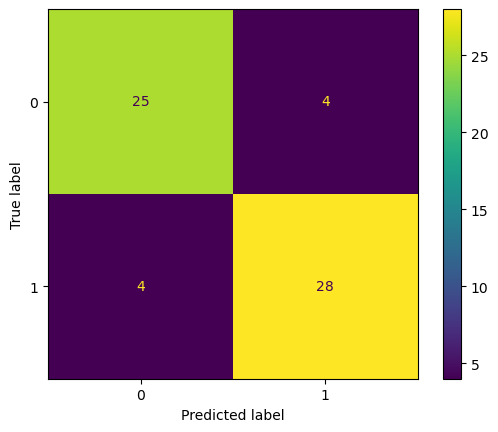

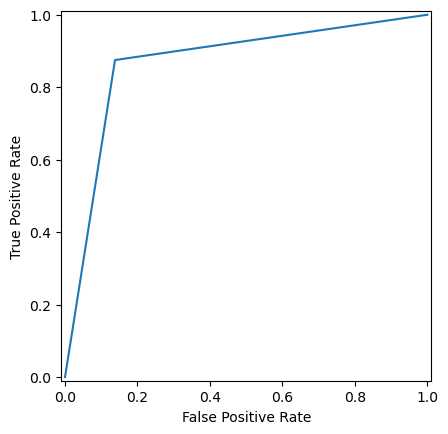

In [36]:
log_searc_model=model_created(LogisticRegression,log_param_grid,X_train,X_test,y_train,y_test)

Fitting 5 folds for each of 28 candidates, totalling 140 fits
accuracy_score:0.6557377049180327
precision_score:0.6896551724137931
recall_score:0.625
              precision    recall  f1-score   support

           0       0.62      0.69      0.66        29
           1       0.69      0.62      0.66        32

    accuracy                           0.66        61
   macro avg       0.66      0.66      0.66        61
weighted avg       0.66      0.66      0.66        61



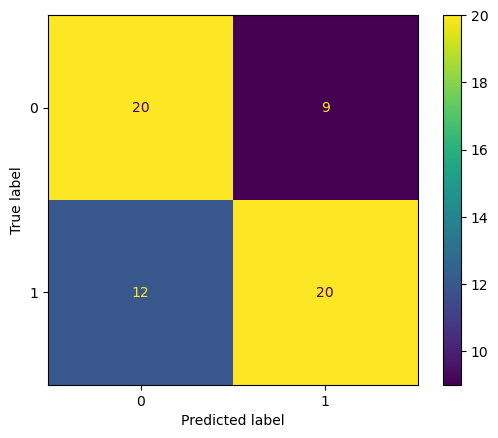

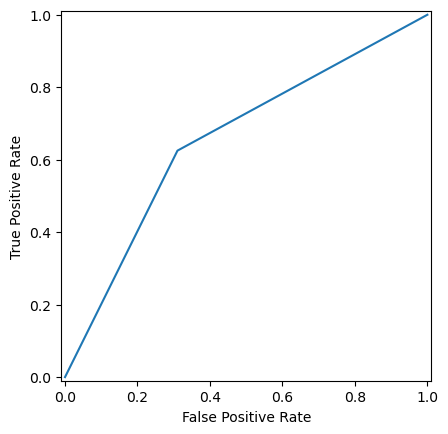

In [54]:
knn_searc_model=model_created(KNeighborsClassifier,knn_param_grid,X_train,X_test,y_train,y_test)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
accuracy_score:0.8032786885245902
precision_score:0.8846153846153846
recall_score:0.71875
              precision    recall  f1-score   support

           0       0.74      0.90      0.81        29
           1       0.88      0.72      0.79        32

    accuracy                           0.80        61
   macro avg       0.81      0.81      0.80        61
weighted avg       0.82      0.80      0.80        61



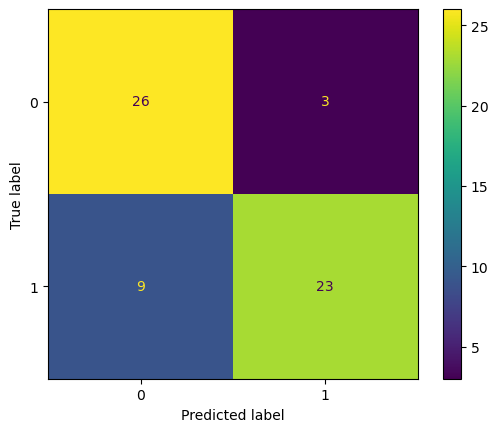

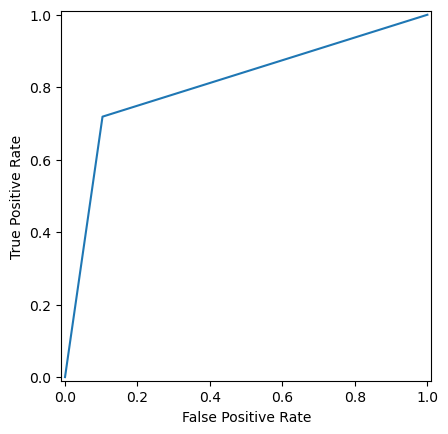

In [38]:
decision_searc_model=model_created(DecisionTreeClassifier,tree_param_grid,X_train,X_test,y_train,y_test)

Fitting 5 folds for each of 84 candidates, totalling 420 fits
accuracy_score:0.8524590163934426
precision_score:0.8484848484848485
recall_score:0.875
              precision    recall  f1-score   support

           0       0.86      0.83      0.84        29
           1       0.85      0.88      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



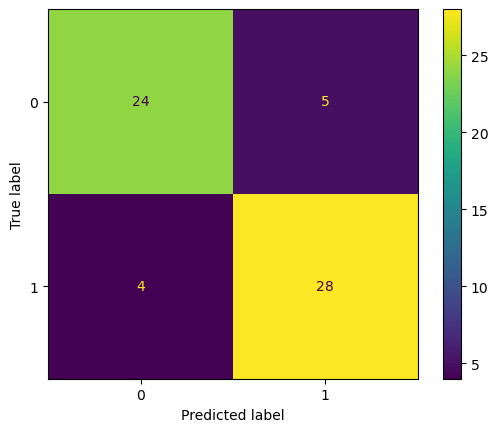

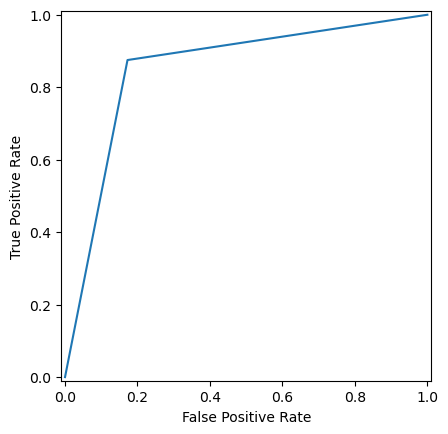

In [39]:
forest_searc_model=model_created(RandomForestClassifier,forest_param_grid,X_train,X_test,y_train,y_test)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
accuracy_score:0.819672131147541
precision_score:0.8888888888888888
recall_score:0.75
              precision    recall  f1-score   support

           0       0.76      0.90      0.83        29
           1       0.89      0.75      0.81        32

    accuracy                           0.82        61
   macro avg       0.83      0.82      0.82        61
weighted avg       0.83      0.82      0.82        61



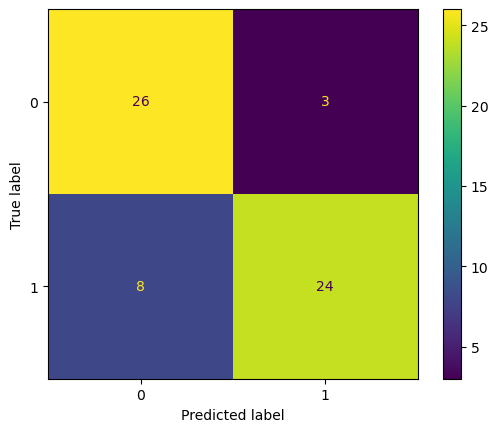

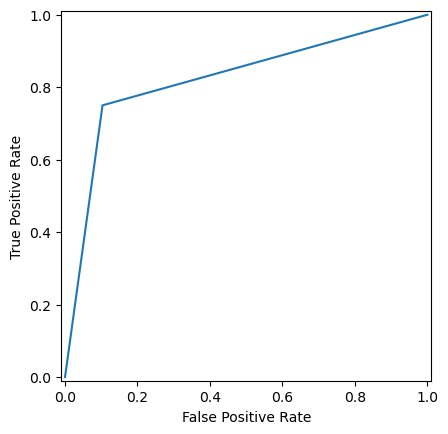

In [40]:
ada_searc_model=model_created(AdaBoostClassifier,ada_param_grid,X_train,X_test,y_train,y_test)

Fitting 5 folds for each of 350 candidates, totalling 1750 fits
accuracy_score:0.819672131147541
precision_score:0.8620689655172413
recall_score:0.78125
              precision    recall  f1-score   support

           0       0.78      0.86      0.82        29
           1       0.86      0.78      0.82        32

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61



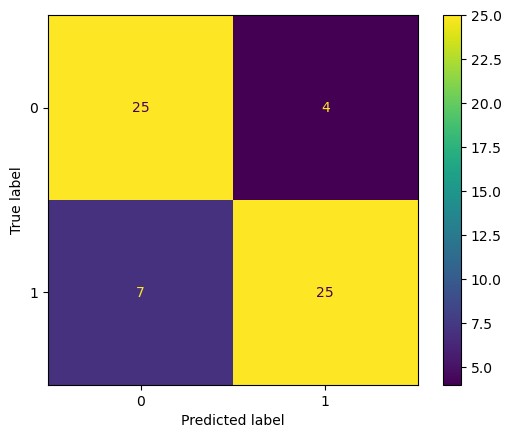

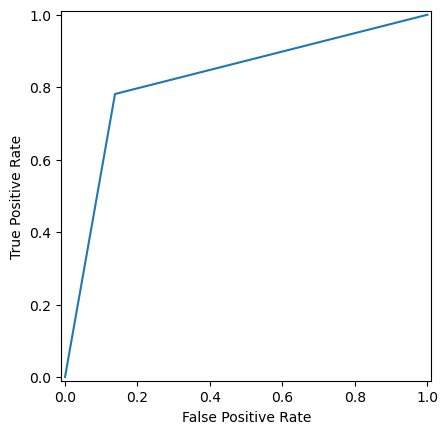

In [41]:
gradient_searc_model=model_created(GradientBoostingClassifier,gradient_param_grid,X_train,X_test,y_train,y_test)

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [43]:
my_dict_search={"Logictic_model":log_searc_model,
        "KNN_mode":knn_searc_model,
        "Decision_tree_model":decision_searc_model,
        "Random_forest_model":forest_searc_model,
        "ada_boost_model":ada_searc_model,
        "gradien_boost_model":gradient_searc_model}
data_search_f=pd.DataFrame(my_dict,index=["accuracy","precision","recall"])

In [44]:
data_search_f

,Logictic_model,KNN_mode,svm_mosel,Decision_tree_model,Random_forest_model,ada_boost_model,gradien_boost_model
accuracy,0.885246,0.688525,0.704918,0.819672,0.852459,0.819672,0.770492
precision,0.878788,0.685714,0.666667,0.888889,0.848485,0.888889,0.800000
recall,0.906250,0.750000,0.875000,0.750000,0.875000,0.750000,0.750000


In [48]:
data_f

,Logictic_model,KNN_mode,svm_mosel,Decision_tree_model,Random_forest_model,ada_boost_model,gradien_boost_model
accuracy,0.885246,0.688525,0.704918,0.819672,0.852459,0.819672,0.770492
precision,0.878788,0.685714,0.666667,0.888889,0.848485,0.888889,0.800000
recall,0.906250,0.750000,0.875000,0.750000,0.875000,0.750000,0.750000
